# 📖 Next Word Predictor using LSTM

A character/word-level **language model** built with a Keras `LSTM` network that learns to predict the next word in a sequence, trained on *The Bard's Best* dataset (a Shakespeare-style text corpus).

**Workflow:**
1. Load and explore the dataset
2. Preprocess and tokenize the text
3. Build n-gram training sequences
4. Pad sequences and prepare features/labels
5. Build, compile, and train an LSTM model
6. Visualize training performance
7. Generate new text with the trained model
8. Evaluate the model on the test set

---
## 1. Environment Setup & Data Discovery

Check what dataset files are available in the Kaggle input directory.


In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/validation.csv
/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/train.csv
/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/test.csv


## 2. Importing Libraries

Import the core libraries used throughout the notebook: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, and Keras/TensorFlow utilities for building and training the LSTM model.

In [35]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras 
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## 3. Loading the Dataset

Load the pre-split **train**, **validation**, and **test** CSV files.

In [3]:
train = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/train.csv')
val = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/validation.csv')
test = pd.read_csv('/kaggle/input/datasets/thedevastator/the-bards-best-a-character-modeling-dataset/test.csv')

### 3.1 Preview the Data

Take a quick look at each split to confirm the data loaded correctly and understand its structure.

In [4]:
train.head()

,text
0,"First Citizen:\nBefore we proceed any further,..."


In [5]:
val.head()

,text
0,"?\n\nGREMIO:\nGood morrow, neighbour Baptista...."


In [6]:
test.head()

,text
0,rance ta'en\nAs shall with either part's agree...


## 4. Text Preprocessing

Combine each split's text column into a single continuous string, which will be tokenized and later broken back down into individual sentences.

In [7]:
train_txt = " ".join(train["text"].astype(str))
val_txt = " ".join(val["text"].astype(str))
test_txt = " ".join(test["text"].astype(str))

### 4.1 Tokenization

Initialize a Keras `Tokenizer` that will build a word-to-index vocabulary from the training text.

In [8]:
tokenizer = Tokenizer()

Fit the tokenizer on the **training text only** (to avoid leaking validation/test vocabulary), and check the resulting vocabulary size.

In [9]:
tokenizer.fit_on_texts([train_txt])
vocab = len(tokenizer.word_index) + 1
print(vocab)

11914


Peek at a sample of the word-to-index mappings the tokenizer learned.

In [10]:
list(tokenizer.word_index.items())[:10]

[('the', 1),
 ('and', 2),
 ('to', 3),
 ('i', 4),
 ('of', 5),
 ('my', 6),
 ('you', 7),
 ('a', 8),
 ('that', 9),
 ('in', 10)]

### 4.2 Converting Sentences to Sequences

Split each corpus back into individual lines/sentences, then convert each sentence into a sequence of token IDs using the fitted tokenizer.

In [11]:
train_sentences = train_txt.split('\n')
val_sentences = val_txt.split('\n')
test_sentences = test_txt.split('\n')

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

Inspect a sample of the tokenized training sequences.

In [12]:
train_sequences[:10]

[[87, 248],
 [143, 34, 962, 145, 609, 127, 16, 106],
 [],
 [35],
 [106, 106],
 [],
 [87, 248],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3, 3678],
 [],
 [35]]

## 5. Creating N-gram Input Sequences

For each tokenized sentence, generate progressively growing n-gram subsequences (e.g. `[w1, w2]`, `[w1, w2, w3]`, ...). Each n-gram's last word becomes the prediction target for the words before it, which is exactly what's needed to train a next-word predictor.

In [13]:
# Train
train_input_sequences = []

for s in train_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        train_input_sequences.append(n_gram)


# Validation
val_input_sequences = []

for s in val_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        val_input_sequences.append(n_gram)


# Test
test_input_sequences = []

for s in test_sequences:
    for i in range(1, len(s)):
        n_gram = s[:i+1]
        test_input_sequences.append(n_gram)

Preview a sample of the generated n-gram sequences.

In [14]:
train_input_sequences[:20]

[[87, 248],
 [143, 34],
 [143, 34, 962],
 [143, 34, 962, 145],
 [143, 34, 962, 145, 609],
 [143, 34, 962, 145, 609, 127],
 [143, 34, 962, 145, 609, 127, 16],
 [143, 34, 962, 145, 609, 127, 16, 106],
 [106, 106],
 [87, 248],
 [7, 41],
 [7, 41, 35],
 [7, 41, 35, 1228],
 [7, 41, 35, 1228, 351],
 [7, 41, 35, 1228, 351, 3],
 [7, 41, 35, 1228, 351, 3, 192],
 [7, 41, 35, 1228, 351, 3, 192, 65],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3],
 [7, 41, 35, 1228, 351, 3, 192, 65, 3, 3678],
 [1228, 1228]]

### 5.1 Determine Maximum Sequence Length

Find the length of the longest n-gram sequence so all sequences can be padded to a uniform length.

In [15]:
max_len = np.max([len(x) for x in train_input_sequences])
max_len

np.int64(16)

### 5.2 Padding Sequences

Pad all sequences (train/validation/test) with leading zeros (`padding='pre'`) so they share the same fixed length, which is required for feeding batches into the LSTM.

In [16]:
# applying padding
train_input_sequences = pad_sequences(
    train_input_sequences,
    maxlen=max_len,
    padding='pre'
)

val_input_sequences = pad_sequences(
    val_input_sequences,
    maxlen=max_len,
    padding='pre'
)

test_input_sequences = pad_sequences(
    test_input_sequences,
    maxlen=max_len,
    padding='pre'
)

Preview a sample of the padded sequences.

In [17]:
train_input_sequences[:10]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  87, 248],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 143,  34],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        143,  34, 962],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,
         34, 962, 145],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34,
        962, 145, 609],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962,
        145, 609, 127],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962, 145,
        609, 127,  16],
       [  0,   0,   0,   0,   0,   0,   0,   0, 143,  34, 962, 145, 609,
        127,  16, 106],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 106, 106],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  87, 248]], dtype=int32)

## 6. Preparing Features (X) and Labels (y)

Split each padded sequence into input words (`X`, all tokens except the last) and the target next word (`y`, the last token).

In [18]:
# Train
X_train = train_input_sequences[:, :-1]
y_train = train_input_sequences[:, -1]

# Validation
X_val = val_input_sequences[:, :-1]
y_val = val_input_sequences[:, -1]

# Test
X_test = test_input_sequences[:, :-1]
y_test = test_input_sequences[:, -1]

Confirm the resulting shapes for the train, validation, and test splits.

In [19]:
print("Shapes :")
print("X_train",X_train.shape)
print("y_train",y_train.shape)

print("X_val",X_val.shape)
print("y_val",y_val.shape)

print("X_test",X_test.shape)
print("y_test",y_test.shape)

Shapes :
X_train (154531, 15)
y_train (154531,)
X_val (8111, 15)
y_val (8111,)
X_test (7801, 15)
y_test (7801,)


### 6.1 One-Hot Encode the Target Labels

Convert the integer word-index targets into one-hot vectors over the full vocabulary, since the model will output a softmax probability distribution over all words.

In [20]:
# one hot encoding of targets
y_train = to_categorical(y_train, num_classes=vocab)
y_val = to_categorical(y_val, num_classes=vocab)
y_test = to_categorical(y_test, num_classes=vocab)

Preview a sample of the one-hot encoded targets.

In [21]:
y_train[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

Re-check the shapes after one-hot encoding to confirm everything lines up as expected.

In [22]:
print("Shapes :")
print("X_train",X_train.shape)
print("y_train",y_train.shape)

print("X_val",X_val.shape)
print("y_val",y_val.shape)

print("X_test",X_test.shape)
print("y_test",y_test.shape)

Shapes :
X_train (154531, 15)
y_train (154531, 11914)
X_val (8111, 15)
y_val (8111, 11914)
X_test (7801, 15)
y_test (7801, 11914)


## 7. Building the LSTM Model

Define a simple sequential architecture:
- **Embedding layer** — maps word indices to dense 100-dimensional vectors
- **LSTM layer** — 150 units, learns sequential/contextual patterns
- **Dense output layer** — softmax over the vocabulary to predict the next word

In [23]:
# building model

model = Sequential()

model.add(Embedding(input_dim=vocab,output_dim=100,input_length =15))
model.add(LSTM(150))
model.add(Dense(vocab,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-08-12 06:38:08.081231: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 7.1 Model Summary

Inspect the model architecture and parameter counts.

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Model Training

### 8.1 Early Stopping

Monitor validation loss and stop training (restoring the best weights) if it doesn't improve for 3 consecutive epochs, to avoid overfitting and wasted compute.

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

### 8.2 Compiling the Model

Use categorical cross-entropy loss (multi-class classification over the vocabulary), the Adam optimizer, and track accuracy.

In [26]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

### 8.3 Fitting the Model

Train for up to 100 epochs with a batch size of 128, validating on the held-out validation set, with early stopping enabled.

In [27]:
history = model.fit(X_train,y_train,epochs=100,batch_size=128,validation_data=(X_val, y_val),callbacks=early_stop)

Epoch 1/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 98s 79ms/step - accuracy: 0.0384 - loss: 6.8571 - val_accuracy: 0.0358 - val_loss: 6.3994
Epoch 2/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 93s 77ms/step - accuracy: 0.0682 - loss: 6.3359 - val_accuracy: 0.0756 - val_loss: 6.1233
Epoch 3/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 92s 76ms/step - accuracy: 0.0912 - loss: 6.0170 - val_accuracy: 0.0842 - val_loss: 6.0156
Epoch 4/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 94s 78ms/step - accuracy: 0.1020 - loss: 5.7803 - val_accuracy: 0.0890 - val_loss: 5.9742
Epoch 5/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 91s 75ms/step - accuracy: 0.1102 - loss: 5.5771 - val_accuracy: 0.0955 - val_loss: 5.9556
Epoch 6/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 93s 77ms/step - accuracy: 0.1174 - loss: 5.3896 - val_accuracy: 0.0953 - val_loss: 5.9803
Epoch 7/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 95s 78ms/step - accuracy: 0.1241 - loss: 5.2140 - val_accuracy: 0.0995 - val_loss: 6.0225
Epoch 8/100
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 96s 79ms/step - accuracy: 

## 9. Training Visualization

### 9.1 Loss Curve

Plot training vs. validation loss across epochs to check for overfitting/underfitting.

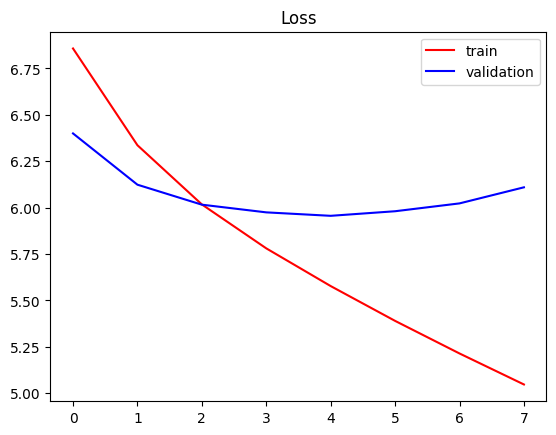

In [28]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

### 9.2 Accuracy Curve

Plot training vs. validation accuracy across epochs.

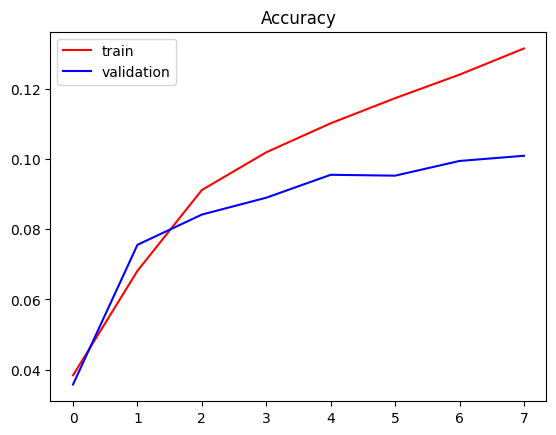

In [29]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

## 10. Next Word Prediction Demo

Use the trained model to iteratively generate new words, one at a time, starting from a seed word — demonstrating the model in action.

In [44]:
text = "york"
for i in range(10):
    # tokenize
    token_txt = tokenizer.texts_to_sequences([text])[0]
    # padding
    input_txt = pad_sequences([token_txt],maxlen=15,padding='pre')
    # predict
    pos = np.argmax(model.predict(input_txt)) # position having highest probablity
    
    for word,index in tokenizer.word_index.items():
        if index == pos:
            text = text + " " + word
print(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
york is the duke of york and i am a man


## 11. Model Evaluation

Define a helper function that runs the model on the test set, computes overall test accuracy, and prints a handful of sample predictions (input context → actual word vs. predicted word) for qualitative inspection.

In [37]:
# Reverse tokenizer mapping: ID -> word
index_word = {index: word for word, index in tokenizer.word_index.items()}

def evaluate_predictions(
    model,
    X_test,
    y_test,
    tokenizer,
    num_samples=20
):
    
    # Predictions
    predictions = model.predict(X_test, verbose=0)
    
    # Predicted word IDs
    y_pred = np.argmax(predictions, axis=1)
    
    # Handle one-hot encoded y_test
    if len(y_test.shape) > 1:
        y_actual = np.argmax(y_test, axis=1)
    else:
        y_actual = y_test
    
    # Test accuracy
    accuracy = accuracy_score(y_actual, y_pred)
    
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print("\nSample Predictions:")
    print("=" * 60)
    
    for i in range(min(num_samples, len(X_test))):
        
        # Convert input IDs -> words
        input_words = [
            index_word.get(idx, "<UNK>")
            for idx in X_test[i]
            if idx != 0
        ]
        
        # Actual and predicted words
        actual_word = index_word.get(
            int(y_actual[i]),
            "<UNK>"
        )
        
        predicted_word = index_word.get(
            int(y_pred[i]),
            "<UNK>"
        )
        
        print("Input:     ", " ".join(input_words))
        print("Actual:    ", actual_word)
        print("Predicted: ", predicted_word)
        print("-" * 60)
    
    return y_actual, y_pred, predictions

Run the evaluation function on the test set.

In [38]:
y_actual, y_pred, predictions = evaluate_predictions(
    model,
    X_test,
    y_test,
    tokenizer,
    num_samples=20
)

Test Accuracy: 0.0902
Test Accuracy: 9.02%

Sample Predictions:
Input:      as
Actual:     shall
Predicted:  i
------------------------------------------------------------
Input:      as shall
Actual:     with
Predicted:  i
------------------------------------------------------------
Input:      as shall with
Actual:     either
Predicted:  the
------------------------------------------------------------
Input:      as shall with either
Actual:     agreement
Predicted:  and
------------------------------------------------------------
Input:      as shall with either agreement
Actual:     stand
Predicted:  to
------------------------------------------------------------
Input:      not
Actual:     in
Predicted:  in
------------------------------------------------------------
Input:      not in
Actual:     my
Predicted:  the
------------------------------------------------------------
Input:      not in my
Actual:     house
Predicted:  heart
------------------------------------------------

---
## 12. Conclusion

This notebook built an end-to-end **next-word prediction** pipeline using an LSTM:

- Text was tokenized and converted into n-gram sequences to frame next-word prediction as a supervised classification problem.
- Sequences were padded and split into inputs (`X`) and one-hot encoded targets (`y`).
- A compact `Embedding → LSTM → Dense(softmax)` model was trained with early stopping to prevent overfitting.
- The trained model was used both to **generate new text** word-by-word and to **evaluate** next-word prediction accuracy on unseen test data.

**Possible next steps:**
- Stack multiple LSTM layers or add `Dropout` for better generalization
- Use pretrained word embeddings (e.g. GloVe) instead of learning embeddings from scratch
- Try beam search or temperature-based sampling for more diverse text generation
- Experiment with a larger vocabulary or subword tokenization (e.g. BPE)
